# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  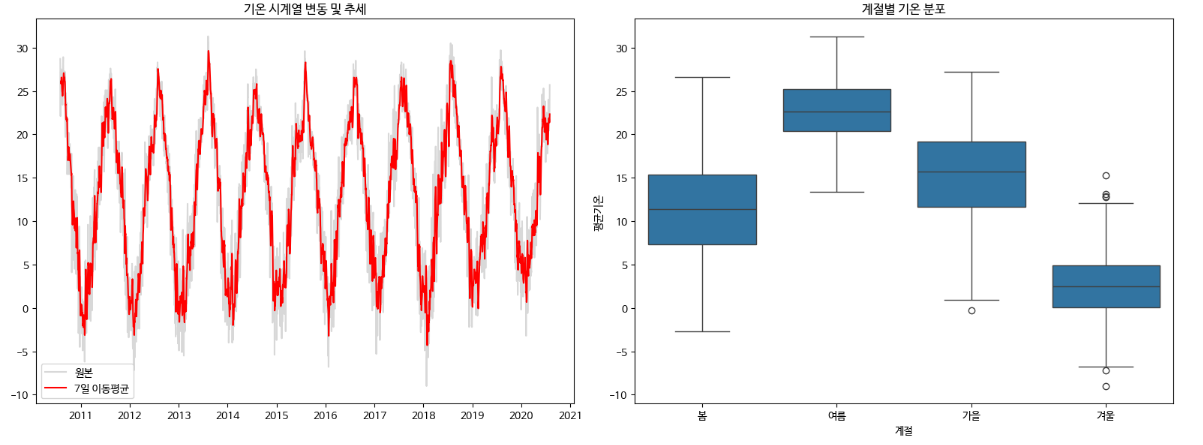

  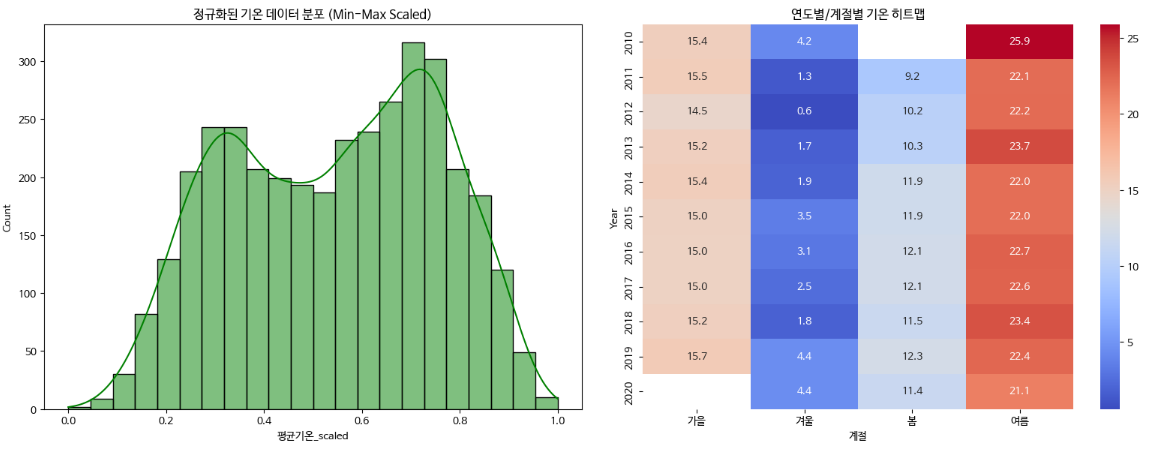



In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_weather_data(url):
    df = pd.read_csv(url, encoding='cp949')
    return df

def preprocess_data(df):
    df['일시'] = pd.to_datetime(df['일시'])
    df.set_index('일시', inplace=True)

    df['7일 이동평균'] = df['평균기온'].rolling(window=7).mean()
    df['Year'] = df.index.year
    df['Month'] = df.index.month

    def get_season(month):
        if month in [3, 4, 5]: return '봄'
        elif month in [6, 7, 8]: return '여름'
        elif month in [9, 10, 11]: return '가을'
        else: return '겨울'

    df['계절'] = df['Month'].apply(get_season)
    return df

def min_max_scale_column(df, column_name):
    min_val = df[column_name].min()
    max_val = df[column_name].max()
    df[f'{column_name}_scaled'] = (df[column_name] - min_val) / (max_val - min_val)
    return df

def analyze_seasonal_stats(df):
    seasonal_stats = df.groupby('계절')['평균기온'].mean().reindex(['봄', '여름', '가을', '겨울'])
    return seasonal_stats

def create_yearly_seasonal_pivot(df):
    pivot_df = df.pivot_table(values='평균기온', index='Year', columns='계절', aggfunc='mean')
    pivot_df = pivot_df[['가을', '겨울', '봄', '여름']]
    return pivot_df

def export_analysis_results(df_processed, seasonal_stats, yearly_pivot, filename='weather_analysis_report.xlsx'):
    with pd.ExcelWriter(filename) as writer:
        df_processed.to_excel(writer, sheet_name='전처리 데이터')
        seasonal_stats.to_excel(writer, sheet_name='계절별 통계')
        yearly_pivot.to_excel(writer, sheet_name='연도별 피벗 테이블')

def plot_time_series_trend(df):
    plt.figure(figsize=(10, 6))
    plt.plot(df.index, df['평균기온'], color='lightgray', linewidth=0.5, label='원본')
    plt.plot(df.index, df['7일 이동평균'], color='red', linewidth=1.5, label='7일 이동평균')
    plt.title('기온 시계열 변동 및 추세')
    plt.xlabel('일시')
    plt.ylabel('평균기온')
    plt.legend(loc='lower left')
    plt.show()

def plot_seasonal_temperature_distribution(df):
    seasons = ['봄', '여름', '가을', '겨울']
    plt.figure(figsize=(10, 8))
    plt.boxplot([df[df['계절'] == s]['평균기온'] for s in seasons], labels=seasons, patch_artist=True)
    plt.title('계절별 기온 분포')
    plt.xlabel('계절')
    plt.ylabel('평균기온')
    plt.show()

def plot_scaled_data_distribution(df_scaled, column_name_scaled):
    plt.figure(figsize=(10, 6))
    sns.histplot(df_scaled[column_name_scaled], kde=True, color='green', bins=25)
    plt.title(f'정규화된 {column_name_scaled} 데이터 분포 (Min-Max Scaled)')
    plt.xlabel(column_name_scaled)
    plt.ylabel('Count')
    plt.show()

def plot_yearly_seasonal_heatmap(yearly_pivot):
    plt.figure(figsize=(10, 8))
    sns.heatmap(yearly_pivot, annot=True, fmt=".1f", cmap='coolwarm', cbar=True)
    plt.title('연도별/계절별 기온 히트맵')
    plt.xlabel('계절')
    plt.ylabel('Year')
    plt.show()


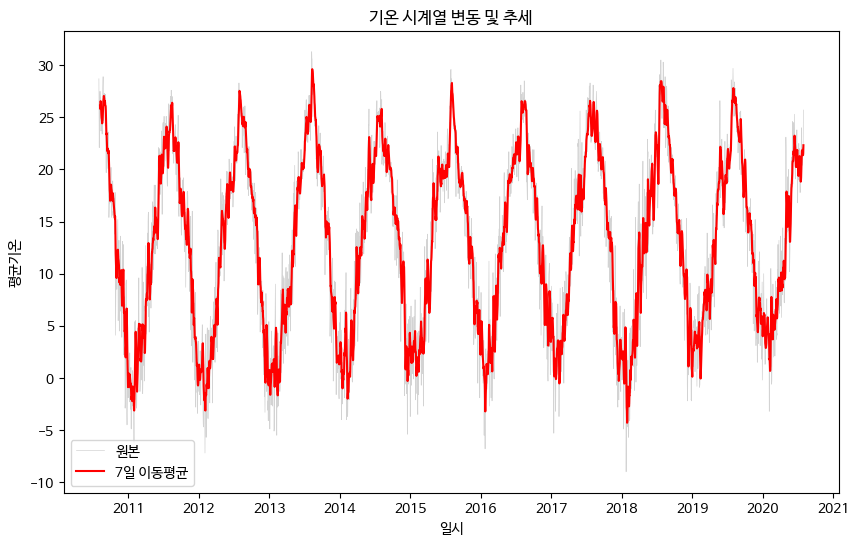

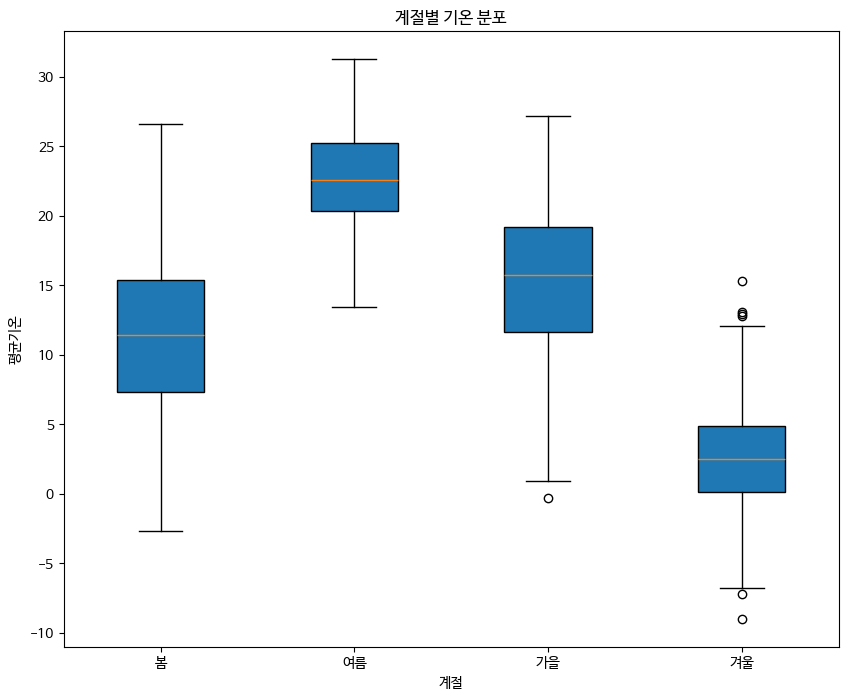

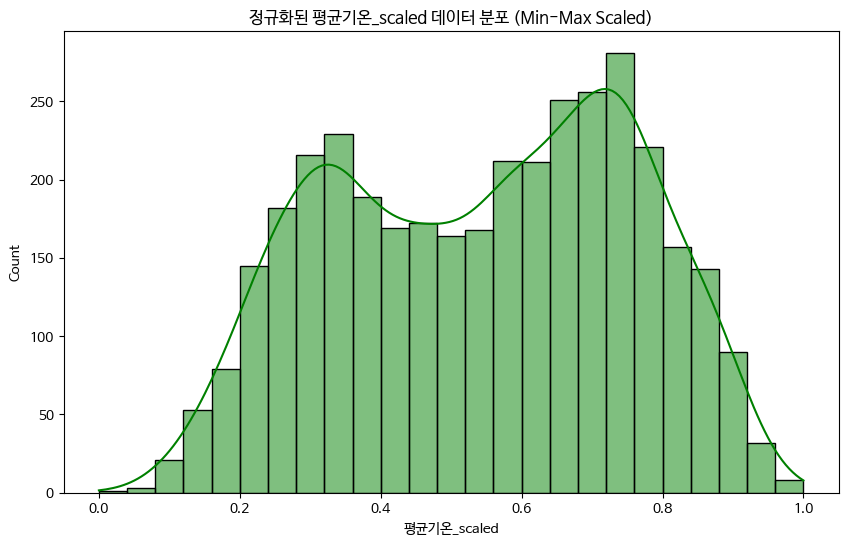

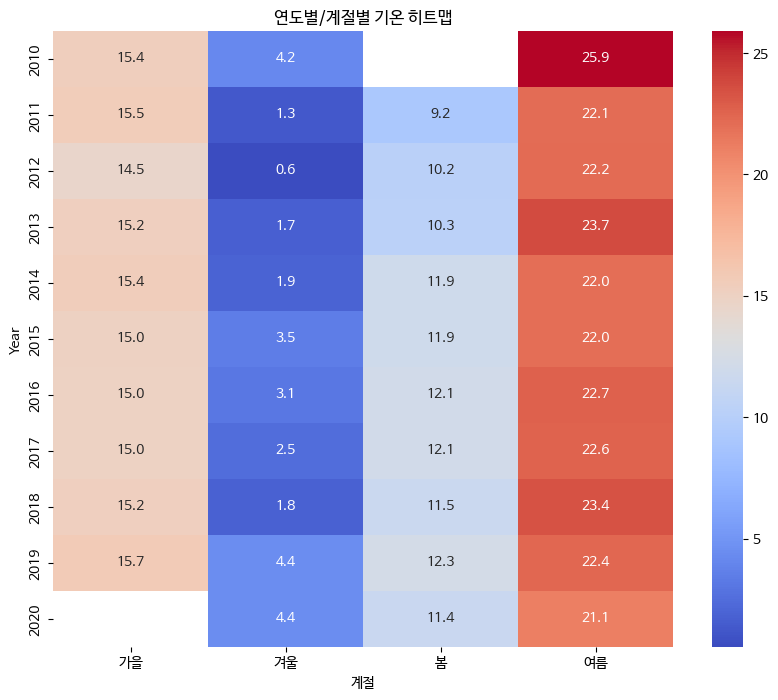

In [15]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings # warnings 모듈 임포트
import os # os 모듈 임포트

def setup_environment():
    warnings.filterwarnings('ignore')

    # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        # Colab 등 리눅스 환경에서 폰트 설치
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 등록
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 윈도우 환경인 경우 'Malgun Gothic'
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False

setup_environment()

def main():
    url = 'https://github.com/dongupak/DataML/raw/main/csv/weather.csv'

    df = load_weather_data(url)

    df_processed = preprocess_data(df.copy())

    df_scaled = min_max_scale_column(df_processed.copy(), '평균기온')

    seasonal_stats = analyze_seasonal_stats(df_processed)
    yearly_pivot = create_yearly_seasonal_pivot(df_processed)

    export_analysis_results(df_scaled, seasonal_stats, yearly_pivot, filename='weather_analysis_report.xlsx')

    plot_time_series_trend(df_processed)
    plot_seasonal_temperature_distribution(df_processed)
    plot_scaled_data_distribution(df_scaled, '평균기온_scaled')
    plot_yearly_seasonal_heatmap(yearly_pivot)

if __name__ == '__main__':
    main()